# Using L3 VIIRS SNPP Data to Generate a Dataset for Analysis

In [1]:
import earthaccess
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import numpy as np
import matplotlib.animation as animation
import os
from PIL import Image, ImageEnhance
import pandas as pd
import scipy.stats as scipy
import matplotlib.patches as mpatches
import cartopy.feature as cfeature

In [2]:
# Enter login information for NASA Earthdata
auth = earthaccess.login(persist=True)

In [3]:
# Search the dataset for an instrument you want to work with
results = earthaccess.search_datasets(instrument = 'viirs', keyword = 'ocean color chlorophyll SNPP') #instrument="aqua") # oci
# For an index (item) in results (the dataset), print the associated products (the summary)
    # In this, you will see the products available from your selected instrument
for item in results:
    summary = item.summary()
    print(summary["short-name"])

VIIRSN_L3b_CHL
VIIRSN_L3b_CHL_NRT
VIIRSN_L3m_CHL
VIIRSN_L3m_CHL_NRT
VIIRSN_L2_OC
VIIRSN_L2_OC_NRT


In [4]:
tspan = ("2012-01-19", "2025-06-30") 
#tspan = ("2025-03-30", "2025-07-20") 
lon_min, lon_max = -128.045, -120.517 #og
lat_min, lat_max = 25.179, 31.164 #og

bbox = (lon_min, lat_min, lon_max, lat_max) # bbox = 'bounding box' so change this to the lat, lon you want to investigate -- originally was (-75, 35, -70, 38)
    # too large: -131.74, 20.12, -114.08,  35.38
clouds = (0,20) #change to (0,100) to see all satellite images that include cloud cover

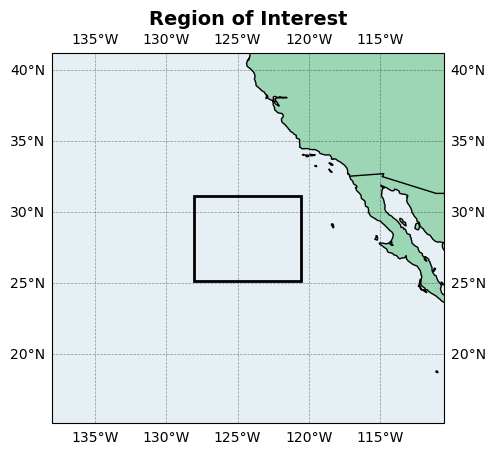

In [6]:
# let's first confirm that our bbox region is our desired area
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor('snow')
num=10
lon_min_ex, lon_max_ex, lat_min_ex, lat_max_ex = lon_min-num, lon_max+num, lat_min-num, lat_max+num
ax.set_extent([lon_min_ex, lon_max_ex, lat_min_ex, lat_max_ex], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor = 'mediumseagreen', alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor = 'lightblue', alpha = 0.3)
ax.add_feature(cfeature.COASTLINE, edgecolor = 'black')
ax.add_feature(cfeature.BORDERS, edgecolor = 'black')
gl = ax.gridlines(draw_labels=True, color='black', alpha=0.4, linewidth=0.5, linestyle='--')
# add box
width = lon_max - lon_min
height = lat_max - lat_min
ax.add_patch(mpatches.Rectangle(xy=[lon_min, lat_min], width=width, height=height, facecolor='none', edgecolor='k', linewidth = 2, transform=ccrs.PlateCarree()))
ax.set_title('Region of Interest', fontsize = 14, fontweight = 'bold')
plt.savefig('/home/jovyan/Desktop/figures/ROI.png', dpi=300, bbox_inches = 'tight')

In [5]:
results = earthaccess.search_data(
    short_name="VIIRSN_L3m_POC", #.DAY.CHL.chlor_a.4km.nc   
    granule_name="*.8D*.4km*", 
            # 8D = 8D (change to just M if you want a monthly view) at 4km resolution (you can change this to even 9 km)
    temporal=tspan,
    bounding_box=bbox
)
paths = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/609 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/609 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/609 [00:00<?, ?it/s]

In [6]:
paths = earthaccess.open(results) #'streaming' data

QUEUEING TASKS | :   0%|          | 0/609 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/609 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/609 [00:00<?, ?it/s]

In [7]:
len(paths)

609

### Use a loop to extract all the data from the files you've opened. 
Relative variables include: The date (will need to get this myself), lat, lon, chl-a </p>
Here is a sample product name: **SNPP_VIIRS.20120101_20250131.L3m.MC.CHL.chlor_a.4km.nc**

In [9]:
# Make some arrays for data to be appended to
# time relative
start_date = []
start_year = []
start_month = []
start_day = []
end_date = []
end_year = []
end_month = []
end_day = []

# statistical lists
chl_a_mean = [] 
chl_a_geometric_mean = []
chl_a_std = []
chl_a_geometric_std = []
chl_a_N = []
chl_a_median = []
chl_a_var = []
chl_a_iqr = []

In [10]:
for i in range(0,len(paths)): #len(paths)): (0,100), (100,200), (200,300), (300, 400), range(400, len(paths))
    datatree = open_datatree(paths[i]) # open the dataset based on that day
    dataset = xr.merge(datatree.to_dict().values()) # merge the datatree to a dictionary format
    dataset = dataset.set_coords(("lon", "lat")) # set the map based on lat and lon # change to lon and lat for L3 data
    # print the file info
    print(dataset.attrs["product_name"])
    # extract the year, month, day of the file
    str_file = str(paths[i].key)     
    date_start = str_file[11:19] 
    ys, ms, ds = str_file[11:15],str_file[15:17],str_file[17:19]
    date_end = str_file[20:28]
    ye, me, de = str_file[20:24],str_file[24:26],str_file[26:28]
    print(f'{ys}, {ms}, {ds}')
    print(f'{ye}, {me}, {de}')

    # create a dataset that selects the points in my ROI
    dataset_masked = dataset.sel(lon=slice(bbox[0], bbox[2]),lat=slice(bbox[3], bbox[1]))
    
    # work with the dataset to get chlor_a cleaned up with no nan values
    chlor_a = dataset_masked['poc']
    
    # drop lat and lon slices where all values are NaN
    chla_cleaned = chlor_a.dropna(dim='lat', how='all').dropna(dim='lon', how='all')
    
    # flatten to 1D numpy array and remove remaining individual NaNs
    chla_flattened = chla_cleaned.values.flatten()
    chla_extracted = chla_flattened[~np.isnan(chla_flattened)]
    
    # count the number of nans in the array
    num_nans = np.isnan(chla_extracted).sum()
    print(f"Number of nans: {num_nans}") 
    #print(len(chlor_a_no_nan))
    
    # finally, we can start the stat. calculations and move forward since all the data has been processed and cleaned!
    chla_mean = np.mean(chla_extracted) #1
    chla_geomean = scipy.gmean(chla_extracted) #2
    chla_median = np.median(chla_extracted) #3
    chla_std = np.std(chla_extracted) #4
    chla_gstd = scipy.gstd(chla_extracted) #5 
    chla_variance = np.var(chla_extracted) #6
    chla_N = chla_extracted.size #7
    chla_iqr = scipy.iqr(chla_extracted) #9
    
    # finally, append lists with the statistical values
    start_date.append(date_start)
    start_year.append(ys)
    start_month.append(ms)
    start_day.append(ds)
    end_date.append(date_end)
    end_year.append(ye)
    end_month.append(me)
    end_day.append(de)
    
    chl_a_mean.append(chla_mean) #1
    chl_a_geometric_mean.append(chla_geomean) #2
    chl_a_median.append(chla_median) #3
    chl_a_std.append(chla_std) #4 
    chl_a_geometric_std.append(chla_gstd) #5
    chl_a_var.append(chla_variance) #6
    chl_a_N.append(chla_N) #7
    chl_a_iqr.append(chla_iqr) #9

SNPP_VIIRS.20120117_20120124.L3m.8D.POC.poc.4km.nc
2012, 01, 17
2012, 01, 24
Number of nans: 0
SNPP_VIIRS.20120125_20120201.L3m.8D.POC.poc.4km.nc
2012, 01, 25
2012, 02, 01
Number of nans: 0
SNPP_VIIRS.20120202_20120209.L3m.8D.POC.poc.4km.nc
2012, 02, 02
2012, 02, 09
Number of nans: 0
SNPP_VIIRS.20120210_20120217.L3m.8D.POC.poc.4km.nc
2012, 02, 10
2012, 02, 17
Number of nans: 0
SNPP_VIIRS.20120218_20120225.L3m.8D.POC.poc.4km.nc
2012, 02, 18
2012, 02, 25
Number of nans: 0
SNPP_VIIRS.20120226_20120304.L3m.8D.POC.poc.4km.nc
2012, 02, 26
2012, 03, 04
Number of nans: 0
SNPP_VIIRS.20120305_20120312.L3m.8D.POC.poc.4km.nc
2012, 03, 05
2012, 03, 12
Number of nans: 0
SNPP_VIIRS.20120313_20120320.L3m.8D.POC.poc.4km.nc
2012, 03, 13
2012, 03, 20
Number of nans: 0
SNPP_VIIRS.20120321_20120328.L3m.8D.POC.poc.4km.nc
2012, 03, 21
2012, 03, 28
Number of nans: 0
SNPP_VIIRS.20120329_20120405.L3m.8D.POC.poc.4km.nc
2012, 03, 29
2012, 04, 05
Number of nans: 0
SNPP_VIIRS.20120406_20120413.L3m.8D.POC.poc.4km.nc

In [13]:
dataset_masked

<xarray.Dataset> Size: 106kB
Dimensions:  (lat: 144, lon: 181, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 576B 31.15 31.1 31.06 31.02 ... 25.27 25.23 25.19
  * lon      (lon) float32 724B -128.0 -128.0 -127.9 ... -120.6 -120.6 -120.5
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    poc      (lat, lon) float32 104kB nan nan nan nan nan ... nan 32.6 34.8 35.0
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      SNPP_VIIRS.20250618_20250625.L3m.8D.PO...
    instrument:                        VIIRS
    title:                             VIIRSN Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          Suomi-NPP
    source:                            satellite observations from VIIRS-Suom...
    ...                                ...
    identifier_product_doi:            10.5067/SUOMI-NPP/VIIRS/L3M/POC/2022
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         12643449
    data_minimum:                      11.006202
    data_maximum:                      1000.0002

In [13]:
#dataset_masked['chlor_a'].plot()
#dataset_masked

In [11]:
viirs = {
    'start date': start_date, 'end_date': end_date,
    'start year': start_year, 'start month': start_month, 'start day': start_day,
    'end year': end_year, 'end month': end_month, 'end day': end_day,
    'POC-a mean': chl_a_mean, 
    'POC geometric mean': chl_a_geometric_mean,
    'POC median': chl_a_median, 
    'POC std': chl_a_std, 
    'POC geometric std': chl_a_geometric_std,
    'POC variance': chl_a_var, 
    'POC N': chl_a_N,
    'POC IQR': chl_a_iqr
}
viirs_df = pd.DataFrame(data=viirs)
viirs_df

,start date,end_date,start year,start month,start day,end year,end month,end day,POC-a mean,POC geometric mean,POC median,POC std,POC geometric std,POC variance,POC N,POC IQR
0,20120117,20120124,2012,01,17,2012,01,24,43.109901,42.210541,40.199707,9.889736,1.215921,97.806877,23691,7.600098
1,20120125,20120201,2012,01,25,2012,02,01,43.325272,42.349018,39.600098,10.548812,1.222027,111.277435,26046,5.399902
2,20120202,20120209,2012,02,02,2012,02,09,39.947941,39.297977,37.000000,8.071814,1.187839,65.154175,26030,6.000000
3,20120210,20120217,2012,02,10,2012,02,17,39.922024,39.119167,36.799805,9.095243,1.210040,82.723457,25712,7.000000
4,20120218,20120225,2012,02,18,2012,02,25,44.967667,43.913082,41.000000,11.399781,1.225484,129.955017,21123,8.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,20250517,20250524,2025,05,17,2025,05,24,35.920639,35.489361,34.399902,6.092541,1.160996,37.119061,17269,5.200195
605,20250525,20250601,2025,05,25,2025,06,01,36.064846,35.777180,35.000000,4.882749,1.130742,23.841240,9624,4.600098
606,20250602,20250609,2025,06,02,2025,06,09,37.698048,37.421444,36.600098,4.765207,1.126569,22.707197,12231,5.200195
607,20250610,20250617,2025,06,10,2025,06,17,33.730476,33.313725,31.600098,5.870558,1.162403,34.463448,20832,4.000000


In [12]:
viirs_df.to_csv('/home/jovyan/Desktop/newest datasets/POC_VIIRS_timeseries_8D_2012-2025.csv')

# For Debugging, Checking, and Clearing/Restarting

In [ ]:
start_date.clear()
start_year.clear()
start_month.clear()
start_day.clear()
end_date.clear()
end_year.clear()
end_month.clear()
end_day.clear()

# statistical lists
chl_a_mean.clear()
chl_a_geometric_mean.clear()
chl_a_geometric_std.clear()
chl_a_std.clear()
chl_a_N.clear()
chl_a_median.clear()
chl_a_var.clear()
chl_a_iqr.clear()

In [ ]:
print(len(chl_a_mean))
print(len(chl_a_geometric_mean))
print(len(chl_a_std))
print(len(chl_a_geometric_std))
print(len(chl_a_N))
print(len(chl_a_var))